In [ ]:
pip install scikit-fuzzy

In [ ]:
import skfuzzy as fuzz
import numpy as np
import skfuzzy.control as ctrl

---
2.11.
---

In [ ]:
R_D=ctrl.Antecedent(np.arange(0,50.5,0.5),'R_D')
T_C=ctrl.Antecedent(np.arange(0,101,1),'T_C')
D_L=ctrl.Antecedent(np.arange(0,101,1),'D_L')
W_C=ctrl.Antecedent(np.arange(0,10,1),'W_C')
C_R=ctrl.Antecedent(np.arange(1,5.5,0.5),'C_R')
R_P=ctrl.Antecedent(np.arange(0,101,1),'R_P')

In [ ]:
Price=ctrl.Consequent(np.arange(10000,101000,1000),'Price')
Reward=ctrl.Consequent(np.arange(10,101,1),'Reward')

In [ ]:
R_D["short"]=fuzz.trimf(R_D.universe,[0,1.5,3.5])
R_D["medium"]=fuzz.trimf(R_D.universe,[1.5,4.5,6.5])
R_D["high"]=fuzz.trimf(R_D.universe,[5.5,11,19])
R_D["very_high"]=fuzz.trapmf(R_D.universe,[14,24,32,48])

T_C["low"]=fuzz.trimf(T_C.universe,[0,12,28])
T_C["medium"]=fuzz.trapmf(T_C.universe,[18,38,62,82])
T_C["high"]=fuzz.trimf(T_C.universe,[68,84,100])

D_L["low"]=fuzz.trimf(D_L.universe,[0,12,28])
D_L["medium"]=fuzz.trapmf(D_L.universe,[18,32,48,72])
D_L["high"]=fuzz.trimf(D_L.universe,[58,78,100])

W_C["bad"]=fuzz.trimf(W_C.universe,[0,1.5,4.5])
W_C["moderate"]=fuzz.trimf(W_C.universe,[3.5,6,8.5])
W_C["good"]=fuzz.trimf(W_C.universe,[6.5,8.2,10])

C_R["poor"]=fuzz.trimf(C_R.universe,[1,1.5,2.5])
C_R["average"]=fuzz.trimf(C_R.universe,[2,3,4])
C_R["good"]=fuzz.trimf(C_R.universe,[3.5,4,5])

R_P["late"]=fuzz.trapmf(R_P.universe,[0,15,30,50])
R_P["on_time"]=fuzz.trimf(R_P.universe,[40,60,80])
R_P["soon"]=fuzz.trimf(R_P.universe,[58,78,100])

In [ ]:
Price["low"]=fuzz.trimf(Price.universe,[10000,20000,40000])
Price["medium"]=fuzz.trimf(Price.universe,[30000,50000,70000])
Price["high"]=fuzz.trimf(Price.universe,[60000,70000,80000])
Price["very_high"]=fuzz.trimf(Price.universe,[70000,100000,100000])

Reward["none"]=fuzz.trapmf(Reward.universe,[0,0,0,1])
Reward["low"]=fuzz.trimf(Reward.universe, [0,20,30])
Reward["medium"]=fuzz.trimf(Reward.universe,[20,40,60])
Reward["high"]=fuzz.trimf(Reward.universe,[50,70,100])

In [ ]:
Grab_ctrl=ctrl.ControlSystem(
    [ctrl.Rule(R_D["short"]&T_C["low"]&D_L["low"], Price["low"]),
     ctrl.Rule(R_D["short"]&T_C["medium"]&D_L["high"], Price["medium"]),
     ctrl.Rule(R_D["medium"]&T_C["high"]&D_L["high"], Price["high"]),
     ctrl.Rule(R_D["high"]&T_C["high"]&W_C["bad"], Price["very_high"]),
     ctrl.Rule(R_D["very_high"]&T_C["high"]&D_L["high"], Price["very_high"]),
     ctrl.Rule(R_D["high"]&T_C["high"]&W_C["good"], Price["medium"]),
     ctrl.Rule(R_D["medium"]&T_C["low"]&D_L["low"], Price["medium"]),
     ctrl.Rule(R_D["short"]&T_C["high"]&W_C["bad"], Price["high"]),
     ctrl.Rule(R_D["very_high"]&W_C["bad"],Price["very_high"]),
     ctrl.Rule(R_D["medium"]&T_C["medium"]&W_C["moderate"],Price["medium"]),
     ctrl.Rule(C_R['good'] & R_P['soon'], Reward['high']),
     ctrl.Rule(C_R['average'] & R_P['on_time'], Reward['medium']),
     ctrl.Rule(C_R['poor'] & R_P['late'], Reward['none']),
     ctrl.Rule(R_D['high'] & T_C['high'] & R_P['on_time'], Reward['high']),
     ctrl.Rule(R_D['medium'] & T_C['high'] & C_R['good'], Reward['medium']),
     ctrl.Rule(C_R['poor'] & R_P['late'], Reward['none']),
     ctrl.Rule(R_D['very_high'] & W_C['bad'] & C_R['good'], Reward['high']),
     ctrl.Rule(R_D['short'] & C_R['average'] & R_P['on_time'], Reward['low']),
     ctrl.Rule(R_D['high'] & T_C['high'] & R_P['late'], Reward['low']),
     ctrl.Rule(R_D['medium'] & W_C['moderate'] & C_R['good'], Reward['medium'])
     ]
    )

88333.33333333333
74.5185185185185


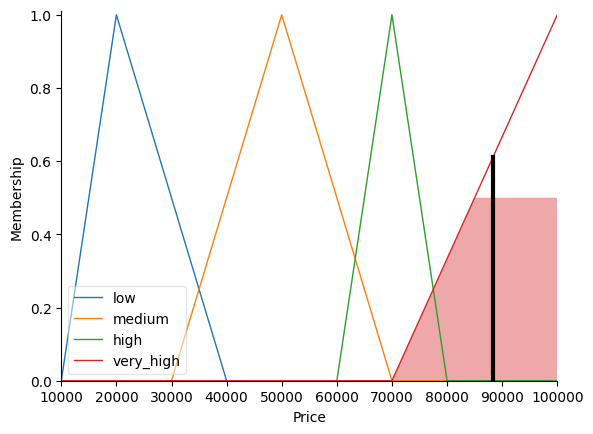

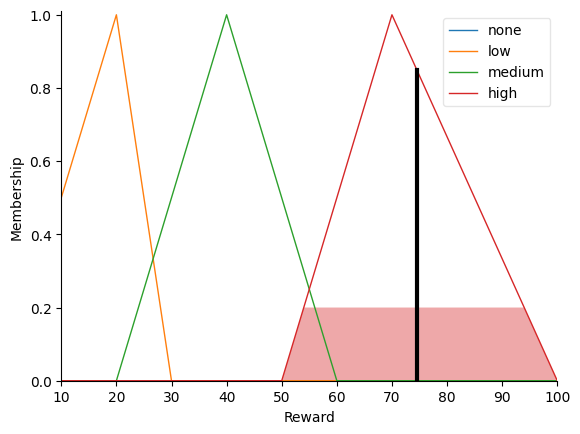

In [ ]:
Grab_sim=ctrl.ControlSystemSimulation(Grab_ctrl)


Grab_sim.input['R_D'] = 20
Grab_sim.input['T_C'] = 85
Grab_sim.input['D_L'] = 90
Grab_sim.input['W_C'] = 5
Grab_sim.input['C_R'] = 4.8
Grab_sim.input['R_P'] = 95
Grab_sim.compute()
print(Grab_sim.output["Price"])
Price.view(sim=Grab_sim)
print(Grab_sim.output["Reward"])
Reward.view(sim=Grab_sim)

---
2.12
---

In [ ]:
S_R=ctrl.Antecedent(np.arange(0,6,1), 'S_R')
S_V=ctrl.Antecedent(np.arange(0,101,1), 'S_V')
P_M=ctrl.Antecedent(np.arange(0,101,1), 'P_M')
S_E=ctrl.Antecedent(np.arange(0,11,1), 'S_E')
C_D=ctrl.Antecedent(np.arange(0,101,1), 'C_D')


In [ ]:
discount=ctrl.Consequent(np.arange(0,71,1), 'discount')

In [ ]:
S_R['low'] = fuzz.trapmf(S_R.universe,[0,0,3,4])
S_R['medium']=fuzz.trimf(S_R.universe,[3,4,4.5])
S_R['high'] = fuzz.trapmf(S_R.universe,[4,4.5,5,5])

S_V['low'] = fuzz.trapmf(S_V.universe,[0,0,20,35])
S_V['medium']=fuzz.trimf(S_V.universe,[20,50,70])
S_V['high'] = fuzz.trapmf(S_V.universe,[60,80,90,100])


P_M['low'] = fuzz.trapmf(P_M.universe,[0,0,20,35])
P_M['medium']=fuzz.trimf(P_M.universe,[20,50,70])
P_M['high'] = fuzz.trapmf(P_M.universe,[60,80,90,100])

S_E['none'] = fuzz.trimf(S_E.universe,[0,0,2])
S_E['medium']=fuzz.trapmf(S_E.universe,[1,2,5,7])
S_E['high'] = fuzz.trapmf(S_E.universe,[5,8,10,10])


C_D['low'] = fuzz.trapmf(C_D.universe,[0,0,20,35])
C_D['medium']=fuzz.trimf(C_D.universe,[30,55,80])
C_D['high'] = fuzz.trapmf(C_D.universe,[60,80,90,100])



In [ ]:
discount['very_low'] = fuzz.trapmf(discount.universe, [0,0,3,6])
discount['low']=fuzz.trimf(discount.universe,[5,7.5,10])
discount['medium']=fuzz.trimf(discount.universe,[8,15,20])
discount['high']=fuzz.trimf(discount.universe,[17,30,45])
discount['very_high'] = fuzz.trapmf(discount.universe,[40, 50, 70, 70])


In [ ]:
Shopee_ctrl = ctrl.ControlSystem([
    ctrl.Rule(S_R['high'] & S_V['high'] & P_M['high'], discount['very_low']),
    ctrl.Rule(S_R['low'] & S_V['low'] & P_M['high'], discount['high']),
    ctrl.Rule(S_E['high'] & C_D['high'], discount['very_high']),
    ctrl.Rule(S_R['medium'] & S_V['medium'] & P_M['medium'], discount['medium']),
    ctrl.Rule(S_R['low'] & P_M['low'] & S_V['high'], discount['very_low']),
    ctrl.Rule(S_R['low'] & S_E['none'], discount['medium']),
    ctrl.Rule(S_V['low'] & P_M['low'], discount['high'])
    ])



44.94879227053139


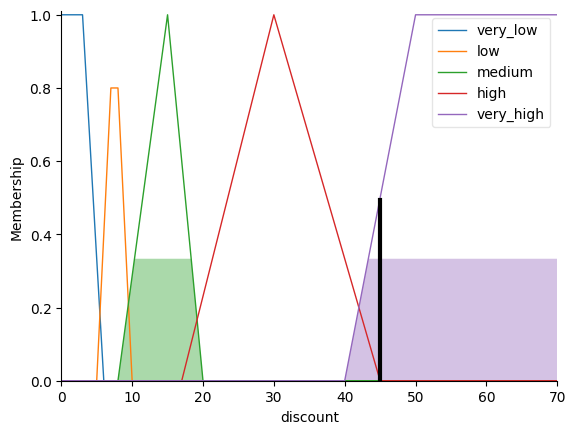

In [ ]:
Shopee_sim = ctrl.ControlSystemSimulation(Shopee_ctrl)

Shopee_sim.input['S_R'] = 4.3
Shopee_sim.input['S_V'] = 50
Shopee_sim.input['P_M'] = 30
Shopee_sim.input['S_E'] = 6
Shopee_sim.input['C_D'] = 70
Shopee_sim.compute()


print(Shopee_sim.output['discount'])
discount.view(sim=Shopee_sim)

---
2.13
---

In [ ]:
P_D = ctrl.Antecedent(np.arange(0, 101, 1), 'P_D')
C_P_P = ctrl.Antecedent(np.arange(0, 101, 1), 'C_P_P')
S_R = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'S_R')
P_M = ctrl.Antecedent(np.arange(0, 101, 1), 'P_M')
S_D = ctrl.Antecedent(np.arange(0, 101, 1), 'S_D')
Discount = ctrl.Consequent(np.arange(0, 71, 1), 'Discount')

In [ ]:
P_D['low'] = fuzz.trapmf(P_D.universe,[0,0,30,60])
P_D['medium'] = fuzz.trimf(P_D.universe,[40,50,70])
P_D['high'] = fuzz.trapmf(P_D.universe,[60,80,90,100])

C_P_P['low'] = fuzz.trapmf(C_P_P.universe, [0,0,30,60])
C_P_P['medium'] = fuzz.trimf(C_P_P.universe, [40,50,70])
C_P_P['high'] = fuzz.trapmf(C_P_P.universe, [60,80,90,100])

S_R['low'] = fuzz.trimf(S_R.universe,[0,3.5,4])
S_R['medium'] = fuzz.trimf(S_R.universe,[3.5, 4, 4.5])
S_R['high'] = fuzz.trimf(S_R.universe,[4,4.5,5])

P_M['low'] = fuzz.trapmf(P_M.universe,[0,10,25,40])
P_M['medium'] = fuzz.trimf(P_M.universe,[30,50,70])
P_M['high'] = fuzz.trapmf(P_M.universe,[60,80,90,100])

S_D['none'] = fuzz.trapmf(S_D.universe,[0,10,30,50])
S_D['medium'] = fuzz.trimf(S_D.universe, [40,50,70])
S_D['high'] = fuzz.trapmf(S_D.universe, [60,80,90,100])

In [ ]:
Discount['very_low'] = fuzz.trapmf(Discount.universe, [0,0,3,6])
Discount['low']=fuzz.trimf(Discount.universe,[5,7.5,10])
Discount['medium']=fuzz.trimf(Discount.universe,[8,15,20])
Discount['high']=fuzz.trimf(Discount.universe,[17,30,50])
Discount['very_high'] = fuzz.trapmf(Discount.universe,[40, 50, 70, 70])

In [ ]:
Shopee_control=ctrl.ControlSystem([
    ctrl.Rule(P_D['high'] & C_P_P['low'] & P_M['low'], Discount['very_low']),
    ctrl.Rule(P_D['low'] & C_P_P['high'] & P_M['high'], Discount['high']),
    ctrl.Rule(S_R['high'] & P_M['high'] & S_D['high'], Discount['medium']),
    ctrl.Rule(C_P_P['high'] & S_D['high'] & P_M['high'], Discount['very_high']),
    ctrl.Rule(S_R['low'] & P_D['medium'] & P_M['low'], Discount['medium']),
    ctrl.Rule(P_D['high'] & S_D['none'] & C_P_P['low'], Discount['very_low']),
    ctrl.Rule(P_M['high'] & C_P_P['medium'] & S_D['medium'], Discount['medium'])
        ]
       )


14.183333333333332


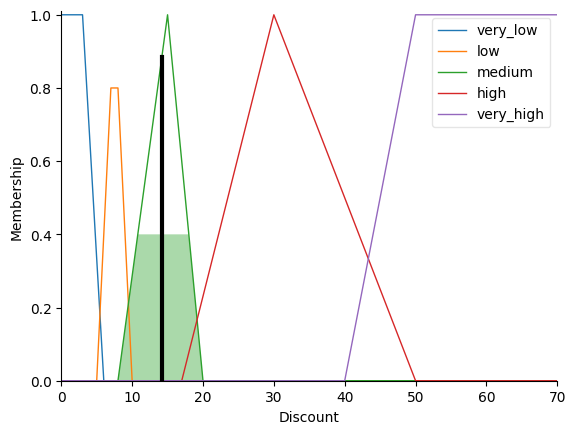

In [ ]:
shopee_sim = ctrl.ControlSystemSimulation(Shopee_control)

shopee_sim.input['P_D'] = 80
shopee_sim.input['C_P_P'] = 55
shopee_sim.input['S_R'] = 4.2
shopee_sim.input['P_M'] = 80
shopee_sim.input['S_D'] = 80

shopee_sim.compute()
print(shopee_sim.output["Discount"])
Discount.view(sim=shopee_sim)

---
2.14
---

In [ ]:
O_D = ctrl.Antecedent(np.arange(0, 101, 1), 'O_D')
D_U = ctrl.Antecedent(np.arange(0, 101, 1), 'D_U')
D_C_L = ctrl.Antecedent(np.arange(0, 101, 1), 'D_C_L')
T_Con = ctrl.Antecedent(np.arange(0, 101, 1), 'T_Con')
P_P_D = ctrl.Antecedent(np.arange(0, 101, 1), 'P_P_D')

OrdertoCombine = ctrl.Consequent(np.arange(0, 11, 1), 'OrdertoCombine')
DeliPrior = ctrl.Consequent(np.arange(0, 11, 1), 'DeliPrior')

In [ ]:
O_D['low'] = fuzz.trapmf(O_D.universe, [0, 0, 30, 60])
O_D['medium'] = fuzz.trimf(O_D.universe, [30, 55, 70])
O_D['high'] = fuzz.trapmf(O_D.universe, [60, 80, 100, 100])

D_U['low'] = fuzz.trapmf(D_U.universe, [0, 0, 30, 60])
D_U['medium'] = fuzz.trimf(D_U.universe, [30, 55, 70])
D_U['high'] = fuzz.trapmf(D_U.universe, [60, 80, 100, 100])

D_C_L['low'] = fuzz.trapmf(D_C_L.universe, [0, 0, 30, 60])
D_C_L['medium'] = fuzz.trimf(D_C_L.universe, [30, 55, 70])
D_C_L['high'] = fuzz.trapmf(D_C_L.universe, [60, 80, 100, 100])

T_Con['low'] = fuzz.trapmf(T_Con.universe, [0, 0, 30, 60])
T_Con['medium'] = fuzz.trimf(T_Con.universe, [30, 55, 80])
T_Con['high'] = fuzz.trimf(T_Con.universe, [60, 85, 100])

P_P_D['low'] = fuzz.trapmf(P_P_D.universe, [0, 0, 30, 60])
P_P_D['medium'] = fuzz.trimf(P_P_D.universe, [30, 55, 70])
P_P_D['high'] = fuzz.trapmf(P_P_D.universe, [60, 80, 95, 100])

In [ ]:
OrdertoCombine['few'] = fuzz.trapmf(OrdertoCombine.universe, [0, 0, 3, 5])
OrdertoCombine['some'] = fuzz.trimf(OrdertoCombine.universe, [4, 5, 7])
OrdertoCombine['many'] = fuzz.trapmf(OrdertoCombine.universe, [6, 8, 10, 10])

DeliPrior['low'] = fuzz.trapmf(DeliPrior.universe, [0, 0, 3, 5])
DeliPrior['medium'] = fuzz.trimf(DeliPrior.universe, [4, 5, 7])
DeliPrior['high'] = fuzz.trapmf(DeliPrior.universe, [6, 8, 10, 10])

In [ ]:
deliver_ctrl = ctrl.ControlSystem([
    ctrl.Rule(O_D['high'] & D_C_L['low'] & T_Con['low'], OrdertoCombine['many']),
    ctrl.Rule(O_D['medium'] & T_Con['high'] & D_U['medium'], OrdertoCombine['few']),
    ctrl.Rule(D_C_L['high'] & O_D['high'] & P_P_D['medium'], OrdertoCombine['some']),
    ctrl.Rule(O_D['low'] & D_U['high'] & T_Con['medium'], OrdertoCombine['few']),
    ctrl.Rule(P_P_D['high'] & T_Con['high'] & D_U['high'], OrdertoCombine['few']),
    ctrl.Rule(D_U['high'] & P_P_D['high'], DeliPrior['high']),
    ctrl.Rule(D_U['medium'] & T_Con['medium'], DeliPrior['medium']),
    ctrl.Rule(D_U['low'] & O_D['high'] & P_P_D['low'], DeliPrior['low'])
  ]
)


8.082125603864736
4.305555555555555


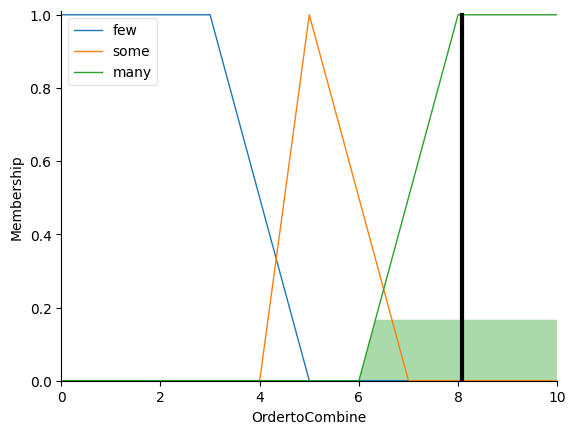

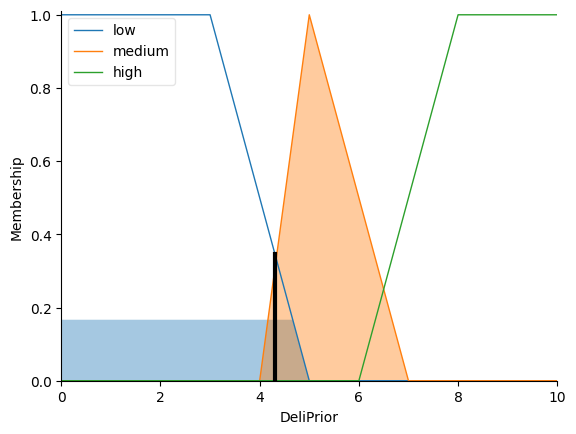

In [ ]:
deliver_sim = ctrl.ControlSystemSimulation(deliver_ctrl)
deliver_sim.input['O_D'] = 95
deliver_sim.input['D_U'] = 55
deliver_sim.input['D_C_L'] = 30
deliver_sim.input['T_Con'] = 55
deliver_sim.input['P_P_D'] = 55

deliver_sim.compute()
print(deliver_sim.output['OrdertoCombine'])
print(deliver_sim.output['DeliPrior'])
OrdertoCombine.view(sim=deliver_sim)
DeliPrior.view(sim=deliver_sim)